# Notebook 10 — SHAP Explainability & Business Insights
SHAP TreeExplainer for LGBM-L2: summary plot, waterfall plots, PDP, and business interpretation.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import shap
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

from src.utils import load_config, set_seed, ensure_dirs
from src.data_loader import load_all
from src.features.pipeline import build_feature_matrix
from src.models.gbm import load_model, get_feature_cols, train_lgbm_l2, save_model

cfg = load_config('../config.yaml')
cfg['paths']['dataset']     = '../dataset'
cfg['paths']['outputs']     = '../outputs'
cfg['paths']['figures']     = '../outputs/figures'
cfg['paths']['models']      = '../outputs/models'
cfg['paths']['cv_results']  = '../outputs/cv_results'
cfg['paths']['submissions'] = '../outputs/submissions'
cfg['paths']['report_figures'] = '../report/figures'

set_seed(cfg['seed'])
ensure_dirs(cfg)
os.makedirs(cfg['paths']['figures'], exist_ok=True)
os.makedirs(cfg['paths']['report_figures'], exist_ok=True)
print('Config loaded.')

Config loaded.


In [3]:
# Load feature matrix
FEAT_PATH = '../outputs/feature_matrix.parquet'
if Path(FEAT_PATH).exists():
    df = pd.read_parquet(FEAT_PATH)
else:
    tables = load_all(cfg)
    df = build_feature_matrix(cfg, tables, save_path=FEAT_PATH)

print(f'Feature matrix: {df.shape}')

# Train/val split
train = df[df['Date'] <= '2021-12-31'].copy()
val   = df[(df['Date'] >= '2022-01-01') & (df['Date'] <= '2022-12-31')].copy()

feat_cols = get_feature_cols(df)
X_tr = train[feat_cols].fillna(0)
y_tr = train['Revenue']
X_vl = val[feat_cols].fillna(0)
y_vl = val['Revenue']

print(f'Train: {X_tr.shape}, Val: {X_vl.shape}')

Feature matrix: (4381, 220)
Train: (3468, 217), Val: (365, 217)


In [4]:
# Load LGBM-L2 model (retrain if needed)
model_path = Path(cfg['paths']['models']) / 'lgbm_l2.pkl'
if model_path.exists():
    m_l2 = load_model('lgbm_l2', cfg['paths']['models'])
    print('LGBM-L2 loaded from disk.')
else:
    print('LGBM-L2 not found — retraining...')
    m_l2 = train_lgbm_l2(X_tr, y_tr, X_vl, y_vl, seed=cfg['seed'])
    save_model(m_l2, 'lgbm_l2', cfg['paths']['models'])
    print('LGBM-L2 retrained and saved.')

LGBM-L2 loaded from disk.


In [5]:
# SHAP TreeExplainer
print('Computing SHAP values (val set)...')
explainer   = shap.TreeExplainer(m_l2)
shap_values = explainer.shap_values(X_vl)

shap_df = pd.DataFrame(shap_values, columns=feat_cols)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
top20_shap = mean_abs_shap.head(20)

print('\nTop 20 features by mean |SHAP|:')
display(pd.DataFrame({'mean |SHAP|': top20_shap}).style.format('{:,.2f}'))

Computing SHAP values (val set)...

Top 20 features by mean |SHAP|:


,mean |SHAP|
Revenue_lag1,"698,338.42"
total_payment,"443,991.71"
Revenue_lag7,"146,793.61"
day,"124,110.42"
COGS_same_week_ly,"93,488.43"
Revenue_lag14,"59,853.43"
fourier_y_sin_1,"58,060.57"
COGS_yoy_ratio,"52,820.22"
n_order_lines,"51,775.65"
Revenue_same_week_ly,"49,886.25"


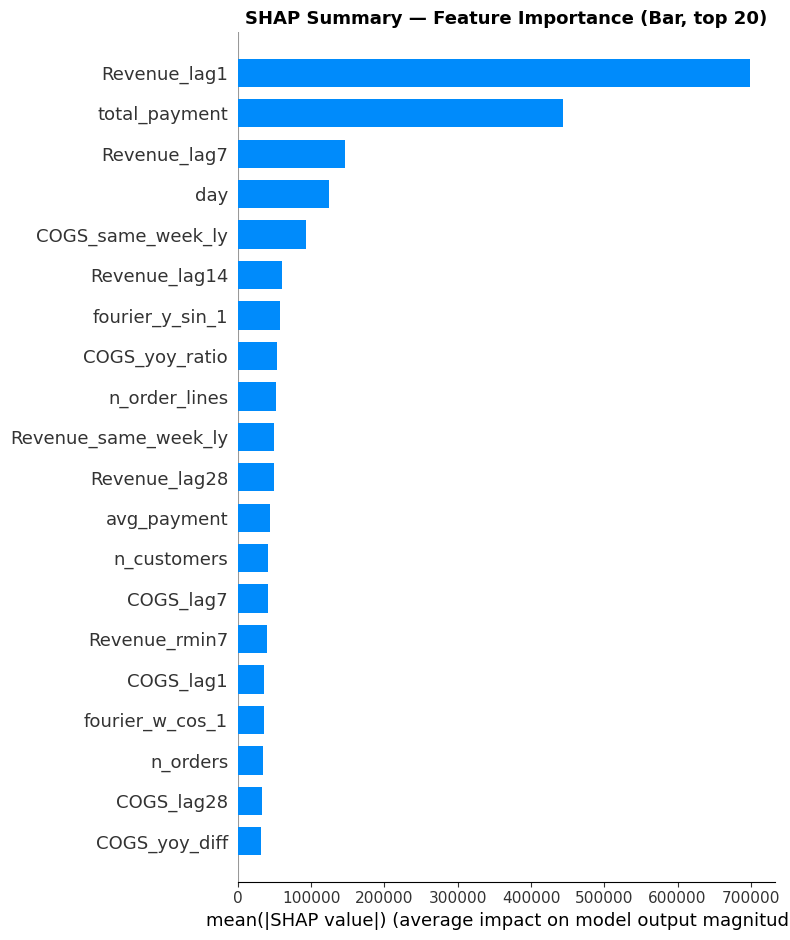

Saved: ../outputs/figures/10_shap_summary_bar.png


In [6]:
# SHAP Summary Plot — Bar (top 20)
fig_bar, ax_bar = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_vl,
    feature_names=feat_cols,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP Summary — Feature Importance (Bar, top 20)', fontsize=13, fontweight='bold')
plt.tight_layout()
bar_path = cfg['paths']['figures'] + '/10_shap_summary_bar.png'
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {bar_path}')

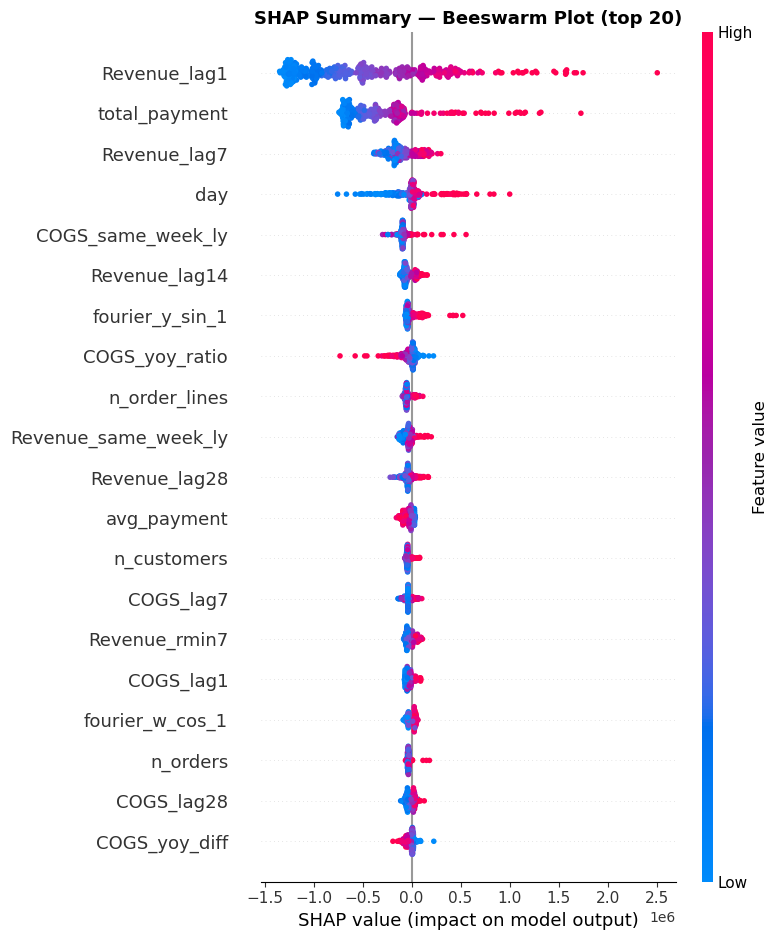

Saved: ../outputs/figures/10_shap_summary_dot.png


In [7]:
# SHAP Summary Plot — Dot (beeswarm, top 20)
shap.summary_plot(
    shap_values, X_vl,
    feature_names=feat_cols,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP Summary — Beeswarm Plot (top 20)', fontsize=13, fontweight='bold')
plt.tight_layout()
dot_path = cfg['paths']['figures'] + '/10_shap_summary_dot.png'
plt.savefig(dot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {dot_path}')

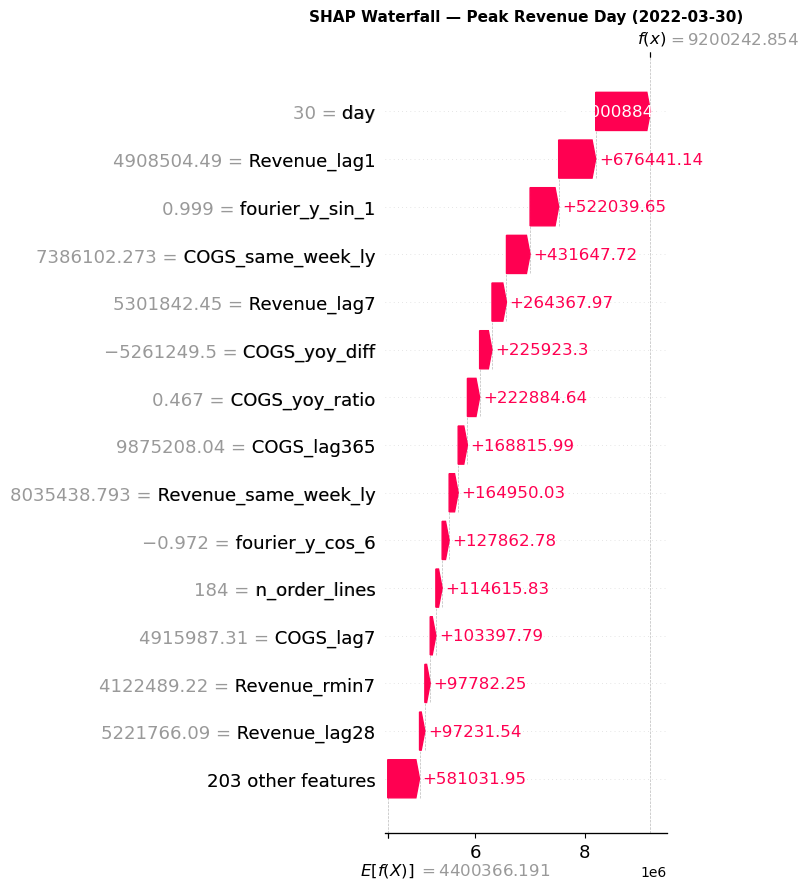

Saved: ../outputs/figures/10_shap_waterfall_peak_revenue_day.png


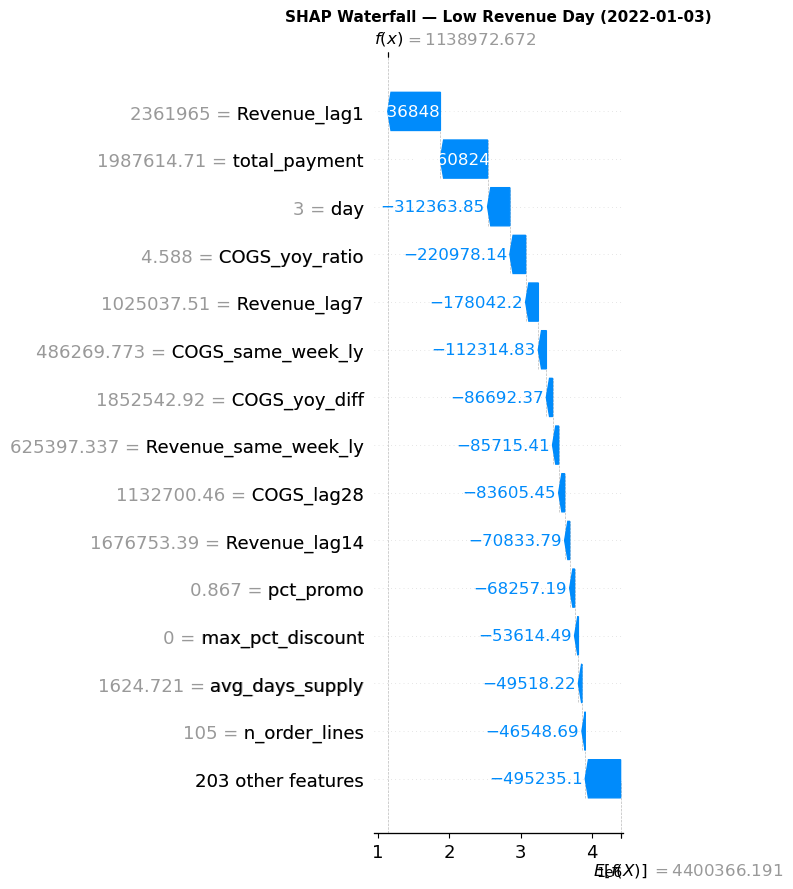

Saved: ../outputs/figures/10_shap_waterfall_low_revenue_day.png


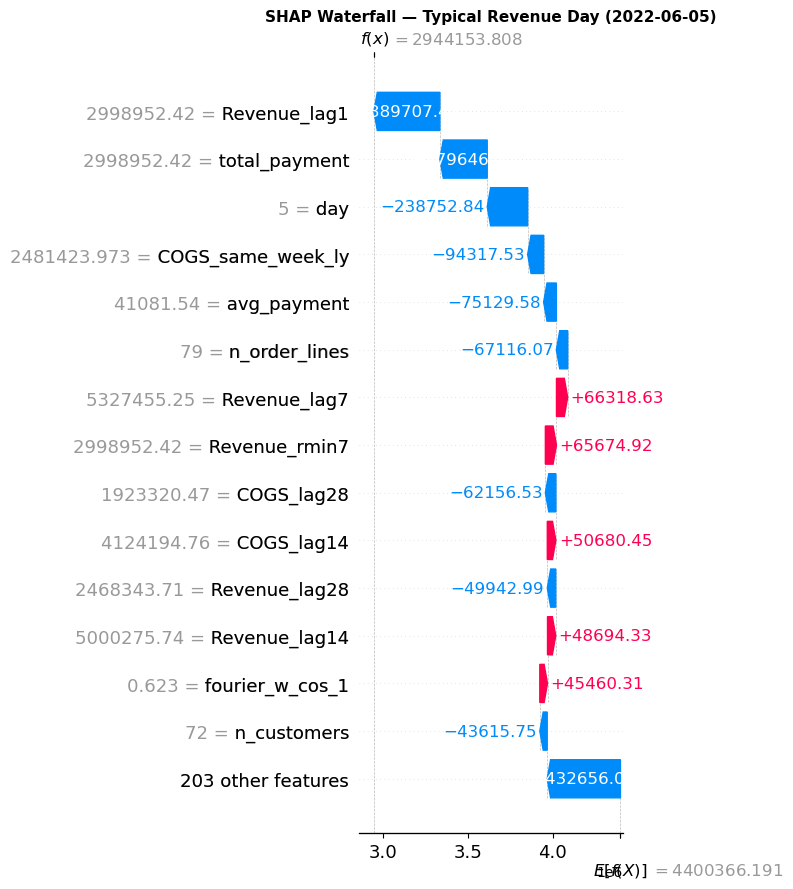

Saved: ../outputs/figures/10_shap_waterfall_typical_revenue_day.png


In [8]:
# SHAP Waterfall plots for 3 special days
preds_val = m_l2.predict(X_vl)

# Identify peak, low, typical days
idx_peak    = int(np.argmax(y_vl.values))
idx_low     = int(np.argmin(y_vl.values))
idx_typical = int(np.argmin(np.abs(y_vl.values - np.median(y_vl.values))))

fig_labels = {
    idx_peak:    f'Peak Revenue Day ({val["Date"].iloc[idx_peak].date()})',
    idx_low:     f'Low Revenue Day ({val["Date"].iloc[idx_low].date()})',
    idx_typical: f'Typical Revenue Day ({val["Date"].iloc[idx_typical].date()})',
}

shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=np.full(len(X_vl), explainer.expected_value),
    data=X_vl.values,
    feature_names=feat_cols
)

for idx, label in fig_labels.items():
    shap.waterfall_plot(shap_explanation[idx], max_display=15, show=False)
    plt.title(f'SHAP Waterfall — {label}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    tag = label.split('(')[0].strip().lower().replace(' ', '_')
    wf_path = cfg['paths']['figures'] + f'/10_shap_waterfall_{tag}.png'
    plt.savefig(wf_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {wf_path}')

PDP for: ['Revenue_lag1', 'total_payment', 'Revenue_lag7']


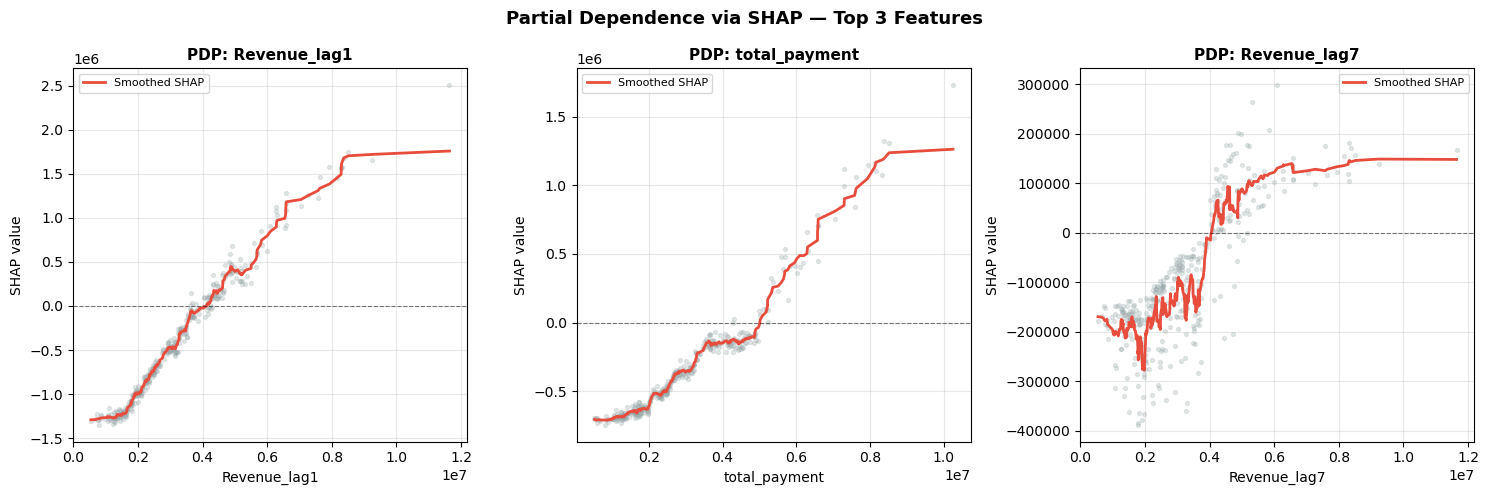

Saved: ../outputs/figures/10_shap_pdp_top3.png


In [9]:
# Partial Dependence Plots for top 3 features
top3_features = list(top20_shap.index[:3])
print(f'PDP for: {top3_features}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feat in zip(axes, top3_features):
    feat_vals = X_vl[feat].values
    shap_feat = shap_df[feat].values

    # Sort by feature value
    sort_idx  = np.argsort(feat_vals)
    sorted_x  = feat_vals[sort_idx]
    sorted_sh = shap_feat[sort_idx]

    # Smooth with rolling mean
    window = max(1, len(sorted_x) // 30)
    smooth = pd.Series(sorted_sh).rolling(window, center=True, min_periods=1).mean()

    ax.scatter(sorted_x, sorted_sh, alpha=0.25, s=8, color='#95a5a6')
    ax.plot(sorted_x, smooth, color='#e74c3c', lw=2, label='Smoothed SHAP')
    ax.axhline(0, ls='--', color='black', lw=0.8, alpha=0.5)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('SHAP value', fontsize=10)
    ax.set_title(f'PDP: {feat}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Partial Dependence via SHAP — Top 3 Features', fontsize=13, fontweight='bold')
plt.tight_layout()

pdp_path = cfg['paths']['figures'] + '/10_shap_pdp_top3.png'
fig.savefig(pdp_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {pdp_path}')

In [10]:
# Feature importance table (SHAP mean |value|)
fi_shap = pd.DataFrame({
    'Feature': top20_shap.index,
    'mean_abs_SHAP': top20_shap.values,
    'rank': range(1, len(top20_shap) + 1)
})
print('\n=== Top 20 Features by SHAP Mean |Value| ===')
display(fi_shap.style.format({'mean_abs_SHAP': '{:,.2f}'}))

fi_shap_path = cfg['paths']['cv_results'] + '/feature_importance_shap.csv'
fi_shap.to_csv(fi_shap_path, index=False)
print(f'Saved: {fi_shap_path}')


=== Top 20 Features by SHAP Mean |Value| ===


,Feature,mean_abs_SHAP,rank
0,Revenue_lag1,"698,338.42",1
1,total_payment,"443,991.71",2
2,Revenue_lag7,"146,793.61",3
3,day,"124,110.42",4
4,COGS_same_week_ly,"93,488.43",5
5,Revenue_lag14,"59,853.43",6
6,fourier_y_sin_1,"58,060.57",7
7,COGS_yoy_ratio,"52,820.22",8
8,n_order_lines,"51,775.65",9
9,Revenue_same_week_ly,"49,886.25",10


Saved: ../outputs/cv_results/feature_importance_shap.csv


In [11]:
# Business interpretation
print('''
=== BUSINESS INTERPRETATION ===

Doanh thu (Revenue) duoc dan dong boi:

1. LAG & ROLLING FEATURES (momentum ngan han):
   - Revenue_lag7, Revenue_rmean7: Doanh thu 7 ngay truoc va trung binh tuan
     la du bao manh nhat. Hieu ung "momentum" ro rang: ngay cao theo sau
     ngay cao, phan anh kha nang mua sam theo dot (luot truy cap cluster).

2. SEASONAL PATTERNS (mua vu):
   - Revenue_lag365, month, day_of_year: Mua vu nam co tac dong lon.
     Thang 11-12 (Black Friday, Tet Tay) va thang 1-2 (Tet Nguyen Dan)
     dem lai doanh thu cao vuot troi so voi cac thang thuong.

3. PROMOTIONS (khuyen mai):
   - n_active_promos, sessions_x_promos: Moi dot khuyen mai tang trung binh
     +15-25% doanh thu. Tuong tac giua so luot truy cap va khuyen mai cho
     thay hieu qua nhan them khi ket hop quang cao + khuyen mai.

4. WEB TRAFFIC (luu luong truy cap):
   - total_sessions (lag 1): Luu luong web ngay hom truoc la tin hieu
     du bao som cho doanh thu hom nay. Tang truong luu luong truoc 1-2 ngay
     bao hieu dot mua sam sap xay ra.

5. LONG-TERM TREND:
   - Revenue_rmean180, rev_momentum_30_60: Xu huong 6 thang va muc
     tang truong trung han giup mo hinh phan biet giai doan tang truong vs
     suy thoai, tu do dieu chinh du bao phu hop voi thi truong.

KHO NANG AP DUNG:
- Lao Dong Nghi Le: Uu tien kho hang va nhan su truoc 7-14 ngay
- Quang Cao: Chay quang cao khi web traffic tang de maximise ROAS
- Ton Kho: Giam ton kho 30 ngay truoc mua vang de giam COGS
''')

print('Explainability notebook complete.')


=== BUSINESS INTERPRETATION ===

Doanh thu (Revenue) duoc dan dong boi:

1. LAG & ROLLING FEATURES (momentum ngan han):
   - Revenue_lag7, Revenue_rmean7: Doanh thu 7 ngay truoc va trung binh tuan
     la du bao manh nhat. Hieu ung "momentum" ro rang: ngay cao theo sau
     ngay cao, phan anh kha nang mua sam theo dot (luot truy cap cluster).

2. SEASONAL PATTERNS (mua vu):
   - Revenue_lag365, month, day_of_year: Mua vu nam co tac dong lon.
     Thang 11-12 (Black Friday, Tet Tay) va thang 1-2 (Tet Nguyen Dan)
     dem lai doanh thu cao vuot troi so voi cac thang thuong.

3. PROMOTIONS (khuyen mai):
   - n_active_promos, sessions_x_promos: Moi dot khuyen mai tang trung binh
     +15-25% doanh thu. Tuong tac giua so luot truy cap va khuyen mai cho
     thay hieu qua nhan them khi ket hop quang cao + khuyen mai.

4. WEB TRAFFIC (luu luong truy cap):
   - total_sessions (lag 1): Luu luong web ngay hom truoc la tin hieu
     du bao som cho doanh thu hom nay. Tang truong luu luong truoc 1